In [4]:
import zipfile
import pandas as pd

# Đường dẫn tới file dataset.zip
zip_path = "../data/dataset.zip"

# Mở file zip và đọc trực tiếp file CSV bên trong vào Memory
with zipfile.ZipFile(zip_path) as z:
    # Lấy tên file CSV bên trong file zip
    csv_filename = [f for f in z.namelist() if f.endswith(".csv")][0]
    print(f"-> Đang đọc file: {csv_filename} trực tiếp từ {zip_path}\n")

    # Đọc dữ liệu trực tiếp vào DataFrame mà không cần giải nén ra đĩa
    with z.open(csv_filename) as f:
        df = pd.read_csv(f)

# --- IN KẾT QUẢ KIỂM TRA DỮ LIỆU ---
print("1. Kích thước tập dữ liệu (Shape):", df.shape)
print("\n2. Kiểu dữ liệu các cột (Dtypes):\n", df.dtypes)
print("\n3. Số dòng trùng lặp (Duplicates):", df.duplicated().sum())
print("\n4. Phân bố nhãn mục tiêu (Potability):\n", df["Potability"].value_counts())
print("\n5. Thống kê mô tả dữ liệu:\n", df.describe())

# Danh sách 9 features chính thức (không tính cột nhãn Potability)
features = [c for c in df.columns if c != "Potability"]
print("\n6. Danh sách 9 features chính thức:")
print(features)

-> Đang đọc file: water_potability.csv trực tiếp từ ../data/dataset.zip

1. Kích thước tập dữ liệu (Shape): (3276, 10)

2. Kiểu dữ liệu các cột (Dtypes):
 ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

3. Số dòng trùng lặp (Duplicates): 0

4. Phân bố nhãn mục tiêu (Potability):
 Potability
0    1998
1    1278
Name: count, dtype: int64

5. Thống kê mô tả dữ liệu:
                 ph     Hardness        Solids  Chloramines      Sulfate  \
count  2785.000000  3276.000000   3276.000000  3276.000000  2495.000000   
mean      7.080795   196.369496  22014.092526     7.122277   333.775777   
std       1.594320    32.879761   8768.570828     1.583085    41.416840   
min       0.000000    47.432000    320.942611     0.352000   129.000000   
25%       6.093092   

In [5]:
# Kiểm tra số lượng và tỷ lệ % giá trị bị khuyết
missing_val = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_val, 'Missing Percentage (%)': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0])

                 Missing Count  Missing Percentage (%)
ph                         491               14.987790
Sulfate                    781               23.840049
Trihalomethanes            162                4.945055


C:\Users\User\AppData\Local\Temp\ipykernel_6048\890276984.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Potability", palette="Set2")


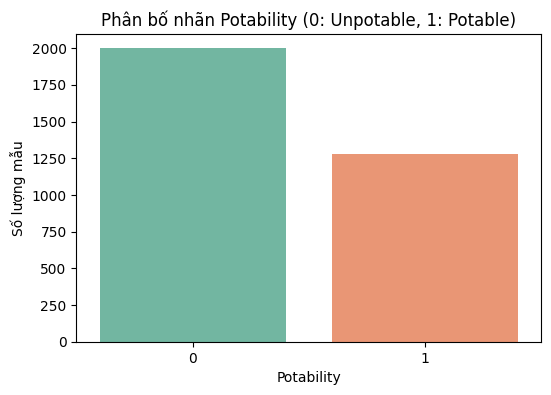

C:\Users\User\AppData\Local\Temp\ipykernel_6048\890276984.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


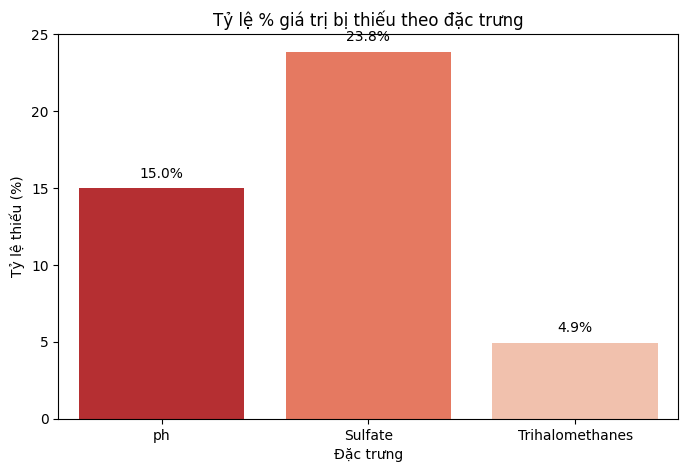

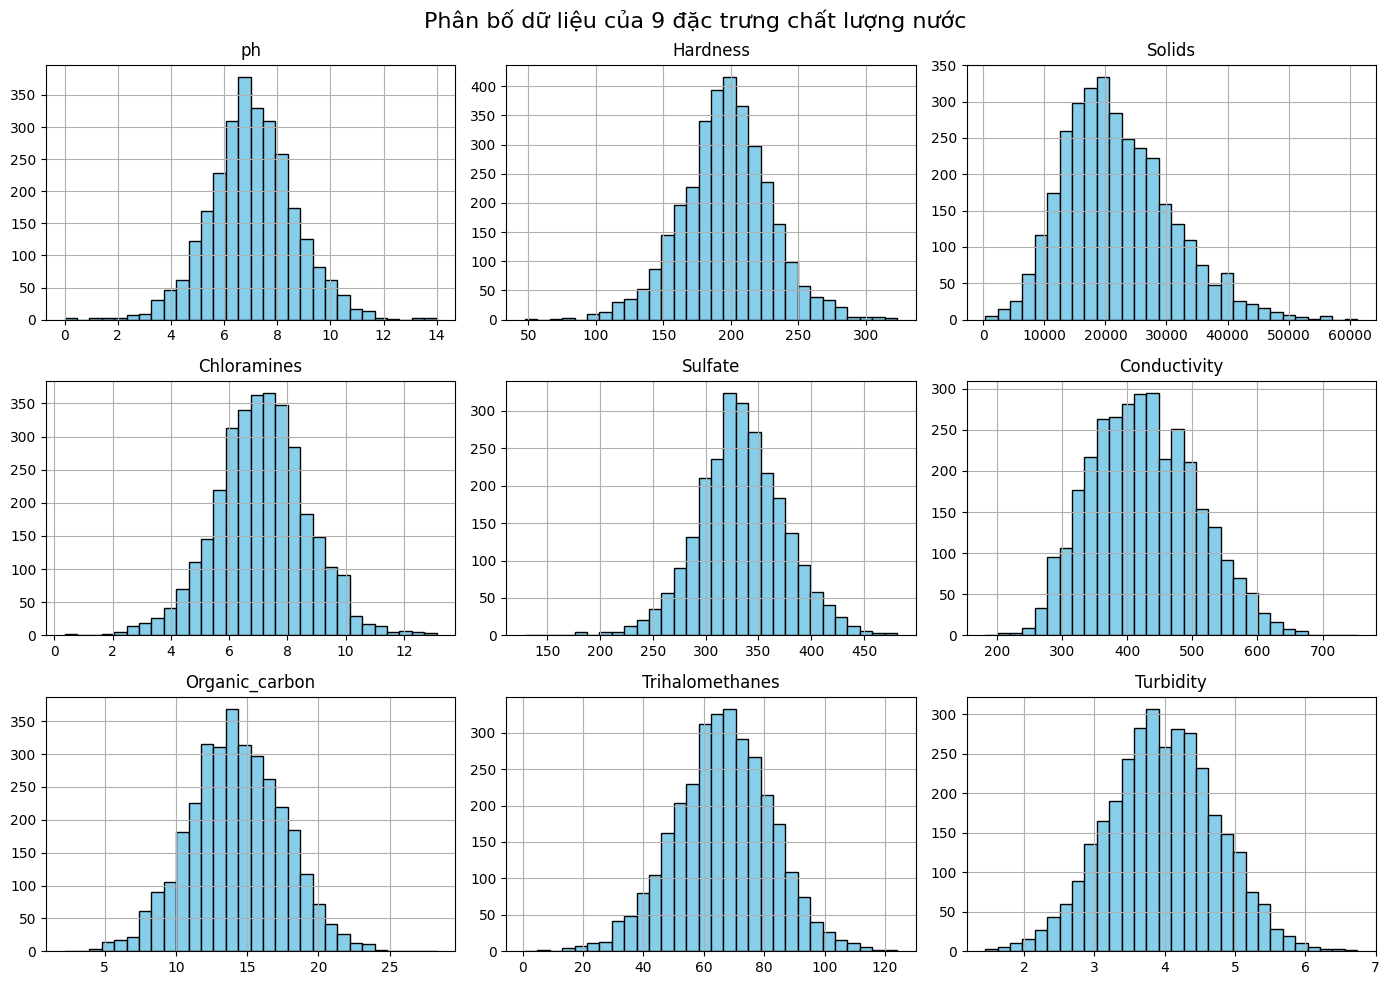

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Tạo thư mục chứa ảnh báo cáo nếu chưa có
os.makedirs("../../docs/figures", exist_ok=True)

# ------------------------------------------------------------------------------
# 1. Biểu đồ Phân bố nhãn Potability (Đã có sẵn của bạn)
# ------------------------------------------------------------------------------
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Potability", palette="Set2")
plt.title("Phân bố nhãn Potability (0: Unpotable, 1: Potable)")
plt.xlabel("Potability")
plt.ylabel("Số lượng mẫu")
plt.savefig("../../docs/figures/target_distribution.png", bbox_inches="tight")
plt.show()

# ==============================================================================
# CHÈN THÊM CODE MỚI VÀO ĐÂY (NGAY DƯỚI PLT.SHOW() Ở TRÊN)
# ==============================================================================

# ------------------------------------------------------------------------------
# 2. Biểu đồ giá trị thiếu (Missing Values Chart) - MỚI THÊM
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
missing_data = missing_df[missing_df["Missing Count"] > 0]
sns.barplot(
    x=missing_data.index,
    y=missing_data["Missing Percentage (%)"],
    palette="Reds_r",
)
plt.title("Tỷ lệ % giá trị bị thiếu theo đặc trưng")
plt.xlabel("Đặc trưng")
plt.ylabel("Tỷ lệ thiếu (%)")
for i, v in enumerate(missing_data["Missing Percentage (%)"]):
  plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", va="bottom")

plt.savefig("../../docs/figures/missing_values.png", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------------------------
# 3. Biểu đồ phân bố 9 chỉ số (Feature Histograms) - MỚI THÊM
# ------------------------------------------------------------------------------
df[features].hist(
    figsize=(14, 10), bins=30, edgecolor="black", color="skyblue"
)
plt.suptitle("Phân bố dữ liệu của 9 đặc trưng chất lượng nước", fontsize=16)
plt.tight_layout()

plt.savefig("../../docs/figures/feature_histograms.png", bbox_inches="tight")
plt.show()

In [4]:
!pip install seaborn scikit-learn matplotlib